import libraries,assets and loaddata

In [1]:
import sys
print(sys.executable)

c:\Users\raeye\portfolio-optimization\.venv\Scripts\python.exe


In [2]:
!python -m pip show yfinance

Name: yfinance
Version: 1.5.1
Summary: Download market data from Yahoo! Finance API
Home-page: https://github.com/ranaroussi/yfinance
Author: Ran Aroussi
Author-email: ran@aroussi.com
License: Apache
Location: c:\Users\raeye\portfolio-optimization\.venv\Lib\site-packages
Requires: beautifulsoup4, curl_cffi, multitasking, numpy, pandas, peewee, platformdirs, protobuf, pytz, requests, websockets
Required-by: 


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.stattools import adfuller
tickers = ["TSLA", "BND", "SPY"]

start_date = "2015-01-01"
end_date = "2026-06-30"
data = {}

for ticker in tickers:
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=False
    )

    data[ticker] = df
    
data["TSLA"].head()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500


saving the data

In [4]:
import os

os.makedirs("../data/processed", exist_ok=True)

for ticker, df in data.items():
    df.to_csv(f"../data/processed/{ticker}.csv")

explore

In [5]:
for ticker, df in data.items():

    print("="*60)
    print(ticker)

    print(df.head())

    print(df.info())

    print(df.describe())

TSLA
Price       Adj Close      Close       High        Low       Open    Volume
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA      TSLA
Date                                                                       
2015-01-02  14.620667  14.620667  14.883333  14.217333  14.858000  71466000
2015-01-05  14.006000  14.006000  14.433333  13.810667  14.303333  80527500
2015-01-06  14.085333  14.085333  14.280000  13.614000  14.004000  93928500
2015-01-07  14.063333  14.063333  14.318667  13.985333  14.223333  44526000
2015-01-08  14.041333  14.041333  14.253333  14.000667  14.187333  51637500
<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, TSLA)  2888 non-null   float64
 1   (Close, TSLA)      2888 non-null   float64
 2   (High, TSLA)       2888 non-null   float64
 3   (Low, TSLA)        2888 non-n

missing values

In [6]:
for ticker, df in data.items():

    print(ticker)

    print(df.isnull().sum())
    df.dropna(inplace=True)

TSLA
Price      Ticker
Adj Close  TSLA      0
Close      TSLA      0
High       TSLA      0
Low        TSLA      0
Open       TSLA      0
Volume     TSLA      0
dtype: int64
BND
Price      Ticker
Adj Close  BND       0
Close      BND       0
High       BND       0
Low        BND       0
Open       BND       0
Volume     BND       0
dtype: int64
SPY
Price      Ticker
Adj Close  SPY       0
Close      SPY       0
High       SPY       0
Low        SPY       0
Open       SPY       0
Volume     SPY       0
dtype: int64


check datatypes

In [7]:
for ticker, df in data.items():

    print(df.dtypes)

Price      Ticker
Adj Close  TSLA      float64
Close      TSLA      float64
High       TSLA      float64
Low        TSLA      float64
Open       TSLA      float64
Volume     TSLA        int64
dtype: object
Price      Ticker
Adj Close  BND       float64
Close      BND       float64
High       BND       float64
Low        BND       float64
Open       BND       float64
Volume     BND         int64
dtype: object
Price      Ticker
Adj Close  SPY       float64
Close      SPY       float64
High       SPY       float64
Low        SPY       float64
Open       SPY       float64
Volume     SPY         int64
dtype: object


In [8]:
data["TSLA"].index

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18',
               '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25',
               '2026-06-26', '2026-06-29'],
              dtype='datetime64[s]', name='Date', length=2888, freq=None)

normalizing the data

In [9]:
scaler = MinMaxScaler()

scaled_close = {}

for ticker, df in data.items():

    scaled_close[ticker] = scaler.fit_transform(df[["Close"]])

closing price plot

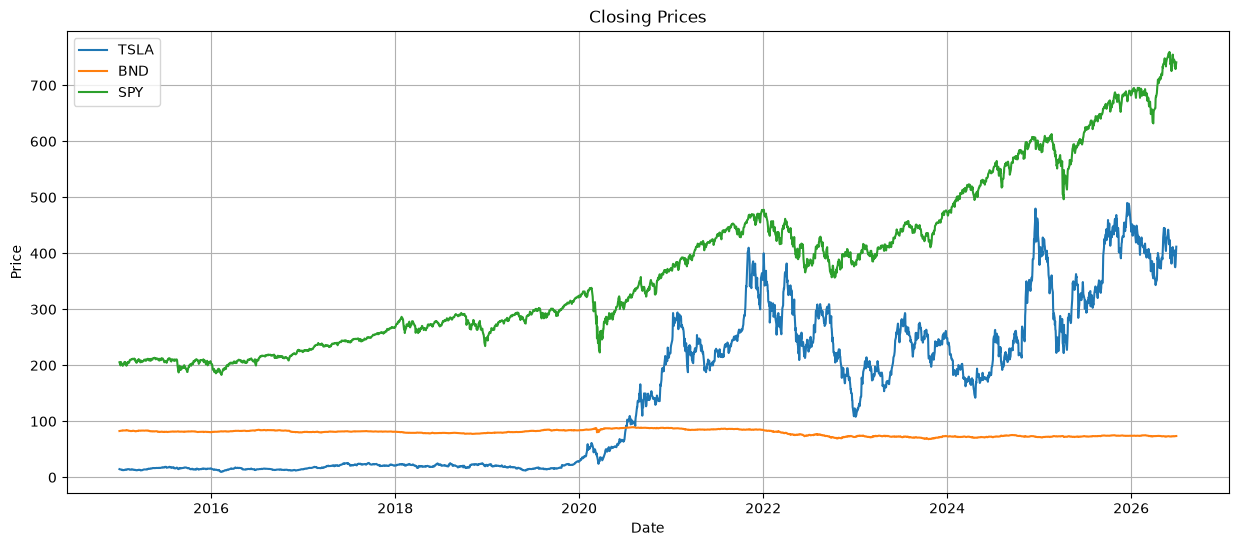

In [10]:
plt.figure(figsize=(15,6))

for ticker in tickers:
    plt.plot(data[ticker]["Close"], label=ticker)

plt.legend()
plt.title("Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)

plt.show()

daily returns and plot

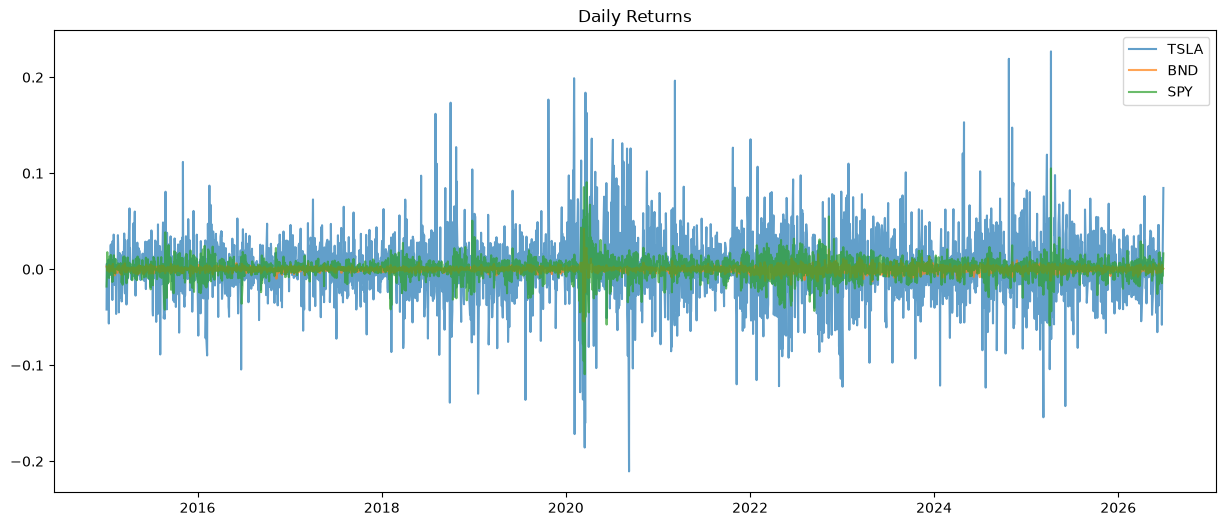

In [11]:
for ticker, df in data.items():

    df["Daily Return"] = df["Close"].pct_change()
plt.figure(figsize=(15,6))

for ticker in tickers:
    plt.plot(
        data[ticker]["Daily Return"],
        label=ticker,
        alpha=0.7
    )
plt.legend()
plt.title("Daily Returns")

plt.show()

rolling mean and plot

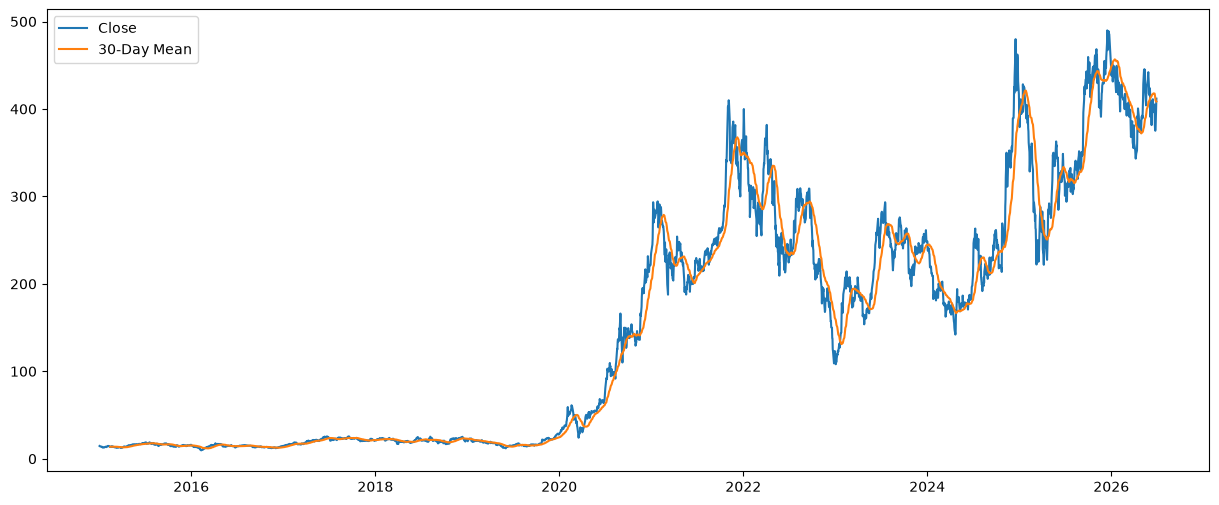

In [12]:
for ticker, df in data.items():

    df["Rolling Mean"] = df["Close"].rolling(30).mean()

    df["Rolling Std"] = df["Close"].rolling(30).std()
plt.figure(figsize=(15,6))

plt.plot(data["TSLA"]["Close"], label="Close")

plt.plot(
    data["TSLA"]["Rolling Mean"],
    label="30-Day Mean"
)

plt.legend()

plt.show()

rolling volatility

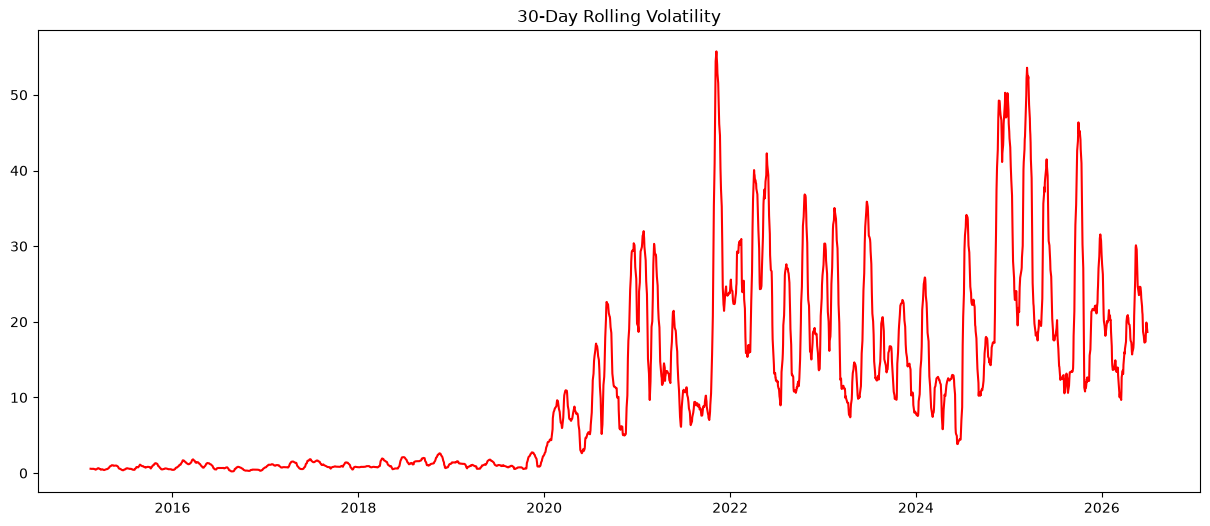

In [13]:
plt.figure(figsize=(15,6))

plt.plot(
    data["TSLA"]["Rolling Std"],
    color="red"
)

plt.title("30-Day Rolling Volatility")

plt.show()

outlier detection

In [14]:
returns = data["TSLA"]["Daily Return"].dropna()

Q1 = returns.quantile(0.25)
Q3 = returns.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = returns[
    (returns < lower) |
    (returns > upper)
]

print(outliers)

Date
2015-08-06   -0.088846
2015-08-27    0.080724
2015-11-04    0.111735
2016-02-02   -0.071900
2016-02-05   -0.072606
                ...   
2025-06-05   -0.142599
2025-06-23    0.082319
2025-07-24   -0.081970
2026-04-15    0.076194
2026-06-29    0.084617
Name: Daily Return, Length: 151, dtype: float64


ADF TEST 

In [15]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):

    result = adfuller(series.dropna())

    print(f"\n{name}")
    print("-" * 40)

    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"P-Value       : {result[1]:.4f}")

    for key, value in result[4].items():
        print(f"Critical Value ({key}) : {value:.4f}")

In [16]:
adf_test(
    data["TSLA"]["Close"],
    "TSLA Close Price"
)


TSLA Close Price
----------------------------------------
ADF Statistic : -1.0696
P-Value       : 0.7270
Critical Value (1%) : -3.4326
Critical Value (5%) : -2.8626
Critical Value (10%) : -2.5673


In [17]:
adf_test(
    data["TSLA"]["Daily Return"],
    "TSLA Daily Returns"
)


TSLA Daily Returns
----------------------------------------
ADF Statistic : -53.9719
P-Value       : 0.0000
Critical Value (1%) : -3.4326
Critical Value (5%) : -2.8625
Critical Value (10%) : -2.5673


var test

In [18]:
var_95 = np.percentile(returns, 5)

print(f"95% VaR: {var_95:.4%}")

95% VaR: -5.1664%


compare asset

In [19]:
for ticker in tickers:

    returns = data[ticker]["Daily Return"].dropna()

    var95 = np.percentile(returns, 5)

    print(f"{ticker}: {var95:.4%}")

TSLA: -5.1664%
BND: -0.5085%
SPY: -1.6741%


historical sharpe

In [20]:
risk_free_rate = 0.02

def sharpe_ratio(returns, risk_free_rate=0.02):

    annual_return = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)

    return (annual_return - risk_free_rate) / annual_volatility


for ticker in tickers:

    returns = data[ticker]["Daily Return"].dropna()

    sr = sharpe_ratio(returns)

    print(f"{ticker}: {sr:.3f}")

TSLA: 0.759
BND: -0.532
SPY: 0.608


histogram

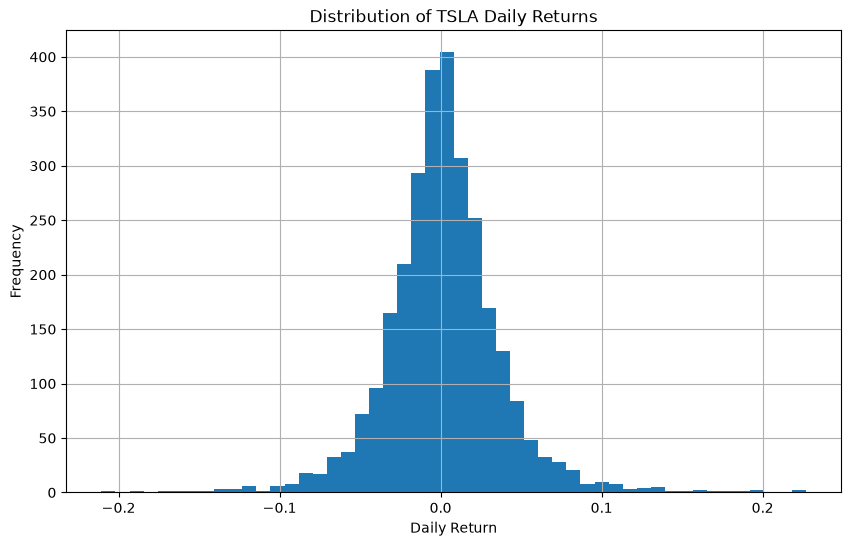

In [21]:
plt.figure(figsize=(10,6))

data["TSLA"]["Daily Return"].hist(bins=50)

plt.title("Distribution of TSLA Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

summary table

In [22]:
summary = []

for ticker in tickers:
    returns = data[ticker]["Daily Return"].dropna()

    summary.append({
        "Ticker": ticker,
        "Mean Return": returns.mean(),
        "Volatility": returns.std(),
        "VaR (95%)": np.percentile(returns, 5),
        "Sharpe Ratio": sharpe_ratio(returns)
    })

summary_df = pd.DataFrame(summary)
summary_df

,Ticker,Mean Return,Volatility,VaR (95%),Sharpe Ratio
0,TSLA,0.001803,0.036018,-0.051664,0.759458
1,BND,-0.000034,0.003383,-0.005085,-0.531649
2,SPY,0.000507,0.011163,-0.016741,0.608028
